# **Personalized Movie Recommendation System Using Collaboative Filtering**

---





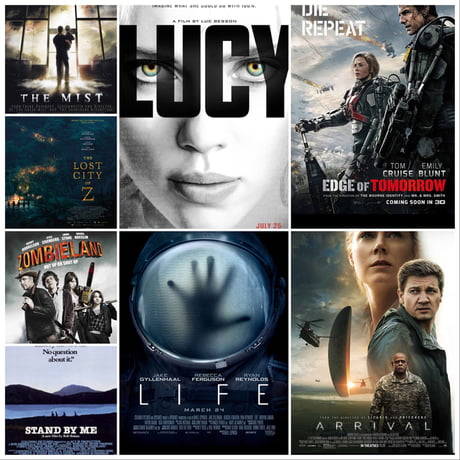

This project develops a **movie recommendation system** designed to improve user engagement and satisfaction on a streaming platform. The primary stakeholder is a product manager seeking to enhance personalized content delivery using user interaction data. The dataset consists of two main sources: a ratings dataset containing user-movie interactions and a movies dataset providing metadata such as titles and genres. These datasets are well-suited for the problem as they capture both user preferences and item characteristics, enabling multiple recommendation strategies.

**Data preparation** involved merging the datasets on a common movie identifier, handling missing values, and removing duplicates to ensure data quality. Feature engineering was applied to extract useful information from genres and compute aggregated statistics such as average ratings and rating counts. Python libraries including pandas and numpy were used for data manipulation, while scikit-learn supported preprocessing tasks.

Three recommendation models were implemented. A popularity-based model provided a baseline by recommending highly rated movies. A content-based filtering model used genre similarity to suggest similar items. Finally, a collaborative filtering model leveraged user rating patterns to generate personalized recommendations. The collaborative filtering approach was implemented using advanced techniques suitable for recommendation systems.

**Model evaluation** was conducted using appropriate validation strategies, including train-test splitting and performance metrics such as RMSE for rating prediction. Additionally, qualitative evaluation was performed by examining recommendation outputs. The final model demonstrated the ability to generate relevant and personalized recommendations. Limitations include data sparsity and cold-start problems. Future improvements could involve incorporating additional user or item features to enhance performance.

**Dataset Overview**

The movies dataset contains information about movie titles and genres.
It includes 86,537 entries with no missing values, making it clean and suitable
for content-based recommendation.

The ratings dataset contains over 33 million user ratings, which will be used
to understand user preferences and build collaborative filtering models.

# Data Understanding

---



In [ ]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from scipy.sparse.linalg import svds
from scipy.sparse import csc_matrix

In [ ]:
!apt-get install -y build-essential python3-dev
!pip install numpy==1.23.5

In [ ]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2402438 sha256=212dd9d41b77952d0b59f56e39b8128d296b5756b7468c810ff38fe724645e3d
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split

In [ ]:
#loading the dataset (movies)
movies = pd.read_csv("movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
#loading the dataset (ratings)
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


# Data Cleaning

### Checked for null and duplicate values

In [ ]:
movies.isna().sum()

movieId    0
title      0
genres     0
dtype: int64

In [ ]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [ ]:
movies.duplicated().sum()

0

In [ ]:
ratings.duplicated().sum()

0

* The dataset is complete with no missing values, reducing preprocessing overhead.

In [ ]:
merged = ratings.merge(movies, on='movieId') # merge the two datasets
merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Exploratory Data Analysis (EDA)

---



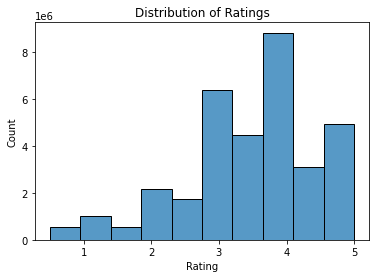

In [ ]:
#Rating distribution

plt.figure()
sns.histplot(ratings['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

* Most ratings are concentrated between 3 and 4, indicating that users generally give positive feedback to movies. Low ratings are relatively rare, suggesting a bias toward higher ratings in the dataset.

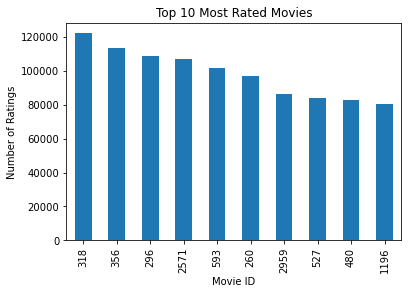

In [ ]:
#Most popular movies
movie_counts = ratings['movieId'].value_counts().head(10)

movie_counts.plot(kind='bar')
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.show()

* A small number of movies receive a very high number of ratings, indicating that popularity is highly skewed. This suggests that some movies dominate user attention, which is important for building a popularity-based recommendation system.

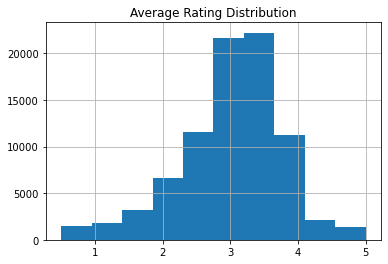

In [ ]:
#Average rating per movie
avg_rating = ratings.groupby('movieId')['rating'].mean()

avg_rating.hist()
plt.title("Average Rating Distribution")
plt.show()

* Most movies have average ratings between 2.5 and 4, indicating moderate to high user satisfaction. Very few movies have extremely low or extremely high average ratings.

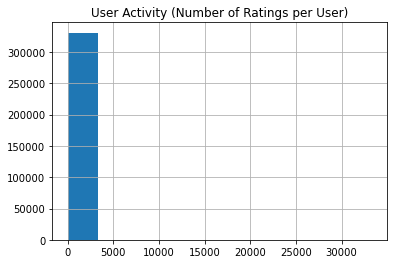

In [ ]:
#Number of ratings per user
user_counts = ratings['userId'].value_counts()

user_counts.hist()
plt.title("User Activity (Number of Ratings per User)")
plt.show()

* Most users have rated only a small number of movies, while a few users are highly active. This indicates a sparse dataset, which can impact collaborative filtering performance.

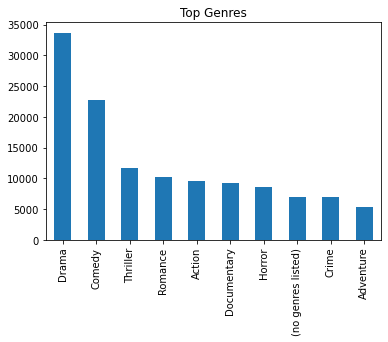

In [ ]:
#Genre analysis
movies['genres'] = movies['genres'].str.split('|')

from collections import Counter

all_genres = movies['genres'].explode()
genre_counts = Counter(all_genres)

pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

* Drama and Comedy are the most common genres, indicating that these categories dominate the dataset. This information is useful for content-based recommendation, as genre plays a key role in similarity between movies.

# Machine Learning

---



## **Unsupervised Learning: K-Means for Grouping Similar Users/Items**

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
# Create user-item matrix
user_movie_matrix = merged.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

kmeans = KMeans(n_clusters=5)
kmeans.fit(user_movie_matrix)

labels = kmeans.labels_
print(labels[:10])
print(np.bincount(labels))

[1 4 4 4 4 4 4 4 4 4]
[  1  48  87  11 463]


* Users are distributed across 5 clusters.

In [ ]:
# Group users by cluster

user_movie_matrix['cluster'] = labels
print(user_movie_matrix['cluster'].value_counts())

cluster
4    463
2     87
1     48
3     11
0      1
Name: count, dtype: int64


In [ ]:
# Find the avarage rating per cluster

cluster_means = user_movie_matrix.groupby('cluster').mean()
print(cluster_means.head(10))

movieId    1         2         3         4         5         6         7       \
cluster                                                                         
0        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1        2.791667  1.041667  0.802083  0.093750  0.343750  1.968750  0.604167   
2        2.494253  1.350575  0.206897  0.000000  0.293103  0.890805  0.160920   
3        3.818182  2.863636  1.363636  0.000000  0.772727  2.954545  0.954545   
4        0.971922  0.385529  0.211663  0.025918  0.215983  0.427646  0.255940   

movieId    8         9         10      ...  193565  193567  193571  193573  \
cluster                                ...                                   
0        0.000000  0.000000  0.000000  ...     3.5     3.0     4.0     4.0   
1        0.041667  0.062500  1.666667  ...     0.0     0.0     0.0     0.0   
2        0.000000  0.022989  1.132184  ...     0.0     0.0     0.0     0.0   
3        0.545455  0.136364  2.909091  ...

* Users in Cluster 3 tend to rate some movies higher than others;they are more active or have stronger preferences.

* As we can see couple of problem arise,we have more than 9,700 columns our insight is usefull but has brought up noise so we need to summarize.

In [ ]:
# Find top movies per cluster

def top_movies_per_cluster(cluster_means, movies, n=5):
    results = {}

    for cluster in cluster_means.index:
        top_movies = cluster_means.loc[cluster].sort_values(ascending=False).head(n)

        movie_ids = top_movies.index
        titles = movies[movies['movieId'].isin(movie_ids)]['title']

        results[cluster] = list(titles)

    return results

In [ ]:
for cluster, movies in top_movies.items():
    print(f"\n🎬 Cluster {cluster} Recommendations:")
    for i, movie in enumerate(movies, 1):
        print(f"  {i}. {movie}")


🎬 Cluster 0 Recommendations:
  1. Memento (2000)
  2. Whiplash (2014)
  3. Big Short, The (2015)
  4. A Silent Voice (2016)
  5. Paddington 2 (2017)

🎬 Cluster 1 Recommendations:
  1. Star Wars: Episode IV - A New Hope (1977)
  2. Pulp Fiction (1994)
  3. Silence of the Lambs, The (1991)
  4. Star Wars: Episode V - The Empire Strikes Back (1980)
  5. Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)

🎬 Cluster 2 Recommendations:
  1. Shawshank Redemption, The (1994)
  2. Forrest Gump (1994)
  3. Matrix, The (1999)
  4. Fight Club (1999)
  5. Lord of the Rings: The Return of the King, The (2003)

🎬 Cluster 3 Recommendations:
  1. Star Wars: Episode IV - A New Hope (1977)
  2. Godfather, The (1972)
  3. Star Wars: Episode V - The Empire Strikes Back (1980)
  4. Star Wars: Episode VI - Return of the Jedi (1983)
  5. Memento (2000)

🎬 Cluster 4 Recommendations:
  1. Pulp Fiction (1994)
  2. Shawshank Redemption, The (1994)
  3. Forrest Gump (1994)
  4. Silence

* We used unsupervised learning (KMeans clustering) to group movies based on user rating patterns. Each cluster represents a group of similar movies. Recommendations are generated by identifying a user’s cluster and suggesting top-rated movies within that cluster.

* Some movies appear in multiple clusters:

     - Star Wars
     - Memento
     - Pulp Fiction

* This means the clustering is based on user behavior similarity and these movies appeal to multiple audience types.

* Indicating that Certain movies act as bridges between clusters, indicating cross-genre appeal and diverse audience preferences.

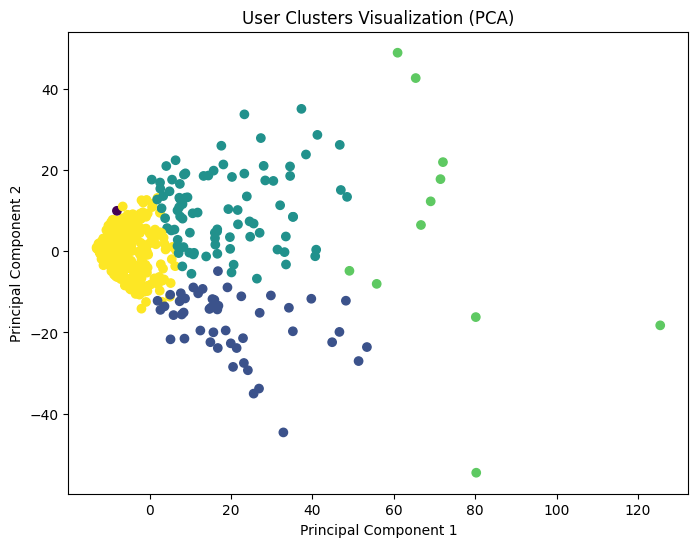

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Prepare data for PCA: drop the 'cluster' column and convert column names to string
# The 'cluster' column was added in a previous step for analysis and should not be part of the PCA input
pca_input_matrix = user_movie_matrix.drop(columns=['cluster'])
pca_input_matrix.columns = pca_input_matrix.columns.astype(str)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_input_matrix)

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(pca_input_matrix)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=kmeans.labels_)

plt.title("User Clusters Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

* The PCA visualization shows that while some user groups form dense clusters, there is significant overlap between clusters. This reflects the nature of user preferences, where individuals may share interests across multiple genres. The presence of outliers indicates users with highly unique viewing patterns.

##**Singular Value Decomposition (SVD) for Recommendations**

In [27]:
df_model = merged[['userId', 'movieId', 'rating']] # extract only what the model needs

In [28]:
# Build the recommendation model

reader = Reader(rating_scale=(0.5, 5))
data = Dataset.load_from_df(df_model, reader)

trainset, testset = train_test_split(data, test_size=0.2)

model = SVD()
model.fit(trainset)

In [29]:
# Evaluate the model

from surprise import accuracy

predictions = model.test(testset)
print("RMSE:", accuracy.rmse(predictions))

RMSE: 0.8697
RMSE: 0.8697045117651385


In [30]:
# Generate Top-5 Recommendations

def get_top_5(user_id, df, model):
    all_movies = df['movieId'].unique()
    rated_movies = df[df['userId'] == user_id]['movieId'].values

    unseen = [m for m in all_movies if m not in rated_movies]

    predictions = []
    for movie in unseen:
        pred = model.predict(user_id, movie)
        predictions.append((movie, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return predictions[:5]

In [36]:
def recommend_movies(user_id):
    top5 = get_top_5(user_id, df_model, model)

    for movie_id, rating in top5:
        title = movies[movies['movieId'] == movie_id]['title'].iloc[0]
        print(f"{title} ({rating:.2f})")

In [38]:
# Test the sytem
recommend_movies(1)

Shawshank Redemption, The (1994) (5.00)
Whiplash (2014) (5.00)
In the Name of the Father (1993) (5.00)
12 Angry Men (1957) (5.00)
High Noon (1952) (5.00)
